In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [22]:
# -------------------------------------------------------------------
# Configuration & data loading
# -------------------------------------------------------------------
crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

df_processed = pd.read_pickle("dataframes/df_processed.pkl")

# Use the same 2013–2022 window as above
df_proc = df_processed[df_processed["year"].between(2013, 2022)].copy()

# -------------------------------------------------------------------
# Create 3 groups (Low / Medium / High) based on mean asylum_per_100k
# grouped by both geo and country
# -------------------------------------------------------------------
intensity_df = (
    df_proc
    .groupby(["geo", "country"], as_index=False)["asylum_per_100k"]
    .mean()
 )

# Split into 3 equal parts (Low 33%, Medium 33%, High 33%) based on mean asylum_per_100k
intensity_df["intake_group"] = pd.qcut(
    intensity_df["asylum_per_100k"],
    q=3,
    labels=["Low", "Medium", "High"],
)

# For later mapping (by geo) keep the same intake_groups structure as before
intake_groups = intensity_df.set_index("geo")[["intake_group"]]

# Print group memberships by country name
print("Group assignment based on mean asylum applications per 100k (2013–2022):")
for level in ["Low", "Medium", "High"]:
    subset = intensity_df.loc[intensity_df["intake_group"] == level, "country"]
    countries = np.sort(subset.unique())
    print(f"\n{level} intake ({len(countries)} countries):")
    print(", ".join(countries))

Group assignment based on mean asylum applications per 100k (2013–2022):

Low intake (10 countries):
Croatia, Czechia, Estonia, Ireland, Latvia, Lithuania, Poland, Portugal, Romania, Slovakia

Medium intake (9 countries):
Bulgaria, Denmark, Finland, France, Italy, Netherlands, Norway, Slovenia, Spain

High intake (10 countries):
Austria, Belgium, Cyprus, Germany, Greece, Hungary, Luxembourg, Malta, Sweden, Switzerland


In [31]:
# -------------------------------------------------------------------
# Prepare per-crime rolling deltas and cohort data (t − (t−1))
# -------------------------------------------------------------------
delta_frames = []
results = []  # store per-crime Low/High delta arrays for later tests/plots

# Map geo -> intake_group once (Low / Medium / High)
group_map = intake_groups["intake_group"].to_dict()

for code, label in crime_codes.items():
    if code not in df_proc.columns:
        continue

    # Crime-specific long slice
    df_crime = df_proc[["geo", "year", code]].rename(columns={code: "crime_per_100k"}).dropna()

    # Map intake groups and keep only Low/High
    df_crime["intake_group"] = df_crime["geo"].map(group_map)
    df_crime = df_crime[df_crime["intake_group"].isin(["Low", "High"])]

    # Sort and compute rolling year-on-year change per country
    df_crime = df_crime.sort_values(["geo", "year"])
    df_crime["delta"] = df_crime.groupby("geo")["crime_per_100k"].diff()
    df_crime = df_crime.dropna(subset=["delta"])  # first year per geo has NaN delta
    if df_crime.empty:
        continue

    low_vals = df_crime.loc[df_crime["intake_group"] == "Low", "delta"]
    high_vals = df_crime.loc[df_crime["intake_group"] == "High", "delta"]
    if len(low_vals) == 0 or len(high_vals) == 0:
        continue

    # Store per-crime data for later use
    df_tmp = df_crime[["geo", "intake_group", "delta"]].copy()
    df_tmp["crime_type"] = label
    delta_frames.append(df_tmp)

    results.append({
        "code": code,
        "label": label,
        "low_vals": low_vals,
        "high_vals": high_vals,
    })

if not delta_frames:
    print("No data available to prepare rolling deltas for any crime code.")
else:
    df_delta_long = pd.concat(delta_frames, ignore_index=True)
    crime_order = [r["label"] for r in results]
    print(f"Prepared rolling deltas (t − (t−1)) for {len(results)} crime types: {', '.join(crime_order)}")

Prepared rolling deltas (t − (t−1)) for 5 crime types: Intentional homicide, Sexual violence, Rape, Robbery, Theft


In [24]:
# -------------------------------------------------------------------
# Run and print Welch t-tests (High vs Low intake) per crime
# -------------------------------------------------------------------
if not results:
    print("No prepared crime data found in 'results'. Run the preparation cell first.")
else:
    for r in results:
        label = r["label"]
        code = r["code"]
        low_vals = r["low_vals"]
        high_vals = r["high_vals"]

        t_stat, p_val = stats.ttest_ind(high_vals, low_vals, equal_var=False)
        mean_high = high_vals.mean()
        mean_low = low_vals.mean()

        print("\n" + "=" * 60)
        print(f"High vs Low intake for {label} ({code})")
        print("=" * 60)
        print(f"Low  intake n={len(low_vals):2d}, mean Δ: {mean_low:.3f}")
        print(f"High intake n={len(high_vals):2d}, mean Δ: {mean_high:.3f}")
        print(f"Difference (High - Low): {mean_high - mean_low:.3f}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value:     {p_val:.4f}")
        if p_val < 0.05:
            print("RESULT: SIGNIFICANT DIFFERENCE (alpha = 0.05)")
        else:
            print("RESULT: No significant difference (alpha = 0.05)")


High vs Low intake for Intentional homicide (ICCS0101)
Low  intake n=90, mean Δ: -0.092
High intake n=90, mean Δ: -0.008
Difference (High - Low): 0.084
T-statistic: 1.4750
P-value:     0.1421
RESULT: No significant difference (alpha = 0.05)

High vs Low intake for Sexual violence (ICCS0301)
Low  intake n=90, mean Δ: 0.566
High intake n=90, mean Δ: 0.283
Difference (High - Low): -0.282
T-statistic: -0.2650
P-value:     0.7915
RESULT: No significant difference (alpha = 0.05)

High vs Low intake for Rape (ICCS03011)
Low  intake n=90, mean Δ: 0.479
High intake n=90, mean Δ: 0.785
Difference (High - Low): 0.306
T-statistic: 0.9633
P-value:     0.3369
RESULT: No significant difference (alpha = 0.05)

High vs Low intake for Robbery (ICCS0401)
Low  intake n=90, mean Δ: -3.282
High intake n=90, mean Δ: -2.606
Difference (High - Low): 0.677
T-statistic: 0.7020
P-value:     0.4837
RESULT: No significant difference (alpha = 0.05)

High vs Low intake for Theft (ICCS0502)
Low  intake n=90, mean Δ: 

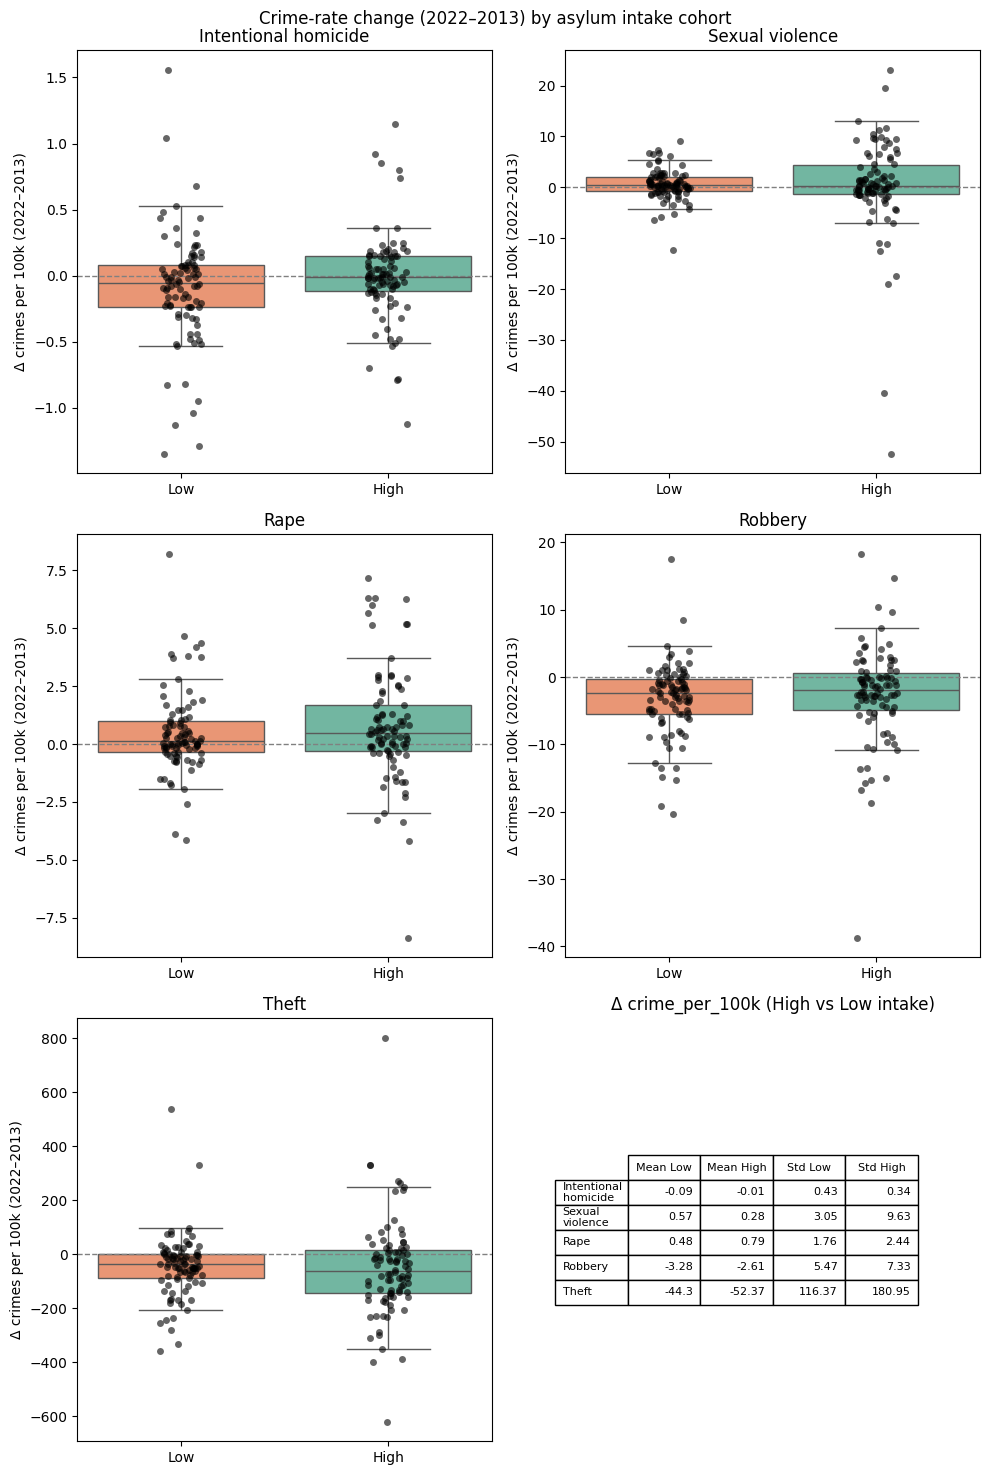

In [25]:
# -------------------------------------------------------------------
# 3x2 grid of High vs Low intake boxplots per crime + summary table
# -------------------------------------------------------------------
if 'df_delta_long' not in globals() or df_delta_long.empty:
    print("No prepared delta data found. Run the preparation cell first.")
else:
    # Use crime_order from preparation; fall back to unique crime_type order if missing
    if 'crime_order' not in globals() or not crime_order:
        crime_order = list(df_delta_long["crime_type"].unique())

    # 3x2 grid: 5 crime plots + 1 table
    fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharex=False)
    axes_flat = axes.flatten()

    # First up to 5 subplots: boxplots per crime type
    for i, crime_name in enumerate(crime_order[:5]):
        ax = axes_flat[i]
        data_sub = df_delta_long[df_delta_long["crime_type"] == crime_name]
        sns.boxplot(
            data=data_sub,
            x="intake_group",
            y="delta",
            hue="intake_group",
            order=["Low", "High"],
            palette="Set2",
            dodge=False,
            showfliers=False,
            ax=ax,
            legend=False,
        )
        sns.stripplot(
            data=data_sub,
            x="intake_group",
            y="delta",
            order=["Low", "High"],
            color="black",
            alpha=0.6,
            jitter=True,
            ax=ax,
        )
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_title(crime_name)
        ax.set_xlabel("")
        ax.set_ylabel("Δ crimes per 100k (2022–2013)")

    # Last subplot: summary table
    table_ax = axes_flat[-1]
    table_ax.axis("off")

    # Build summary stats from 'results'
    stats_rows = []
    for r in results:
        label = r["label"]
        low_vals = r["low_vals"]
        high_vals = r["high_vals"]
        stats_rows.append({
            "Crime": label,
            "Mean Low": low_vals.mean(),
            "Mean High": high_vals.mean(),
            "Std Low": low_vals.std(),
            "Std High": high_vals.std(),
        })

    df_stats = pd.DataFrame(stats_rows)
    df_stats = df_stats[df_stats["Crime"].isin(crime_order)]
    df_stats_round = df_stats.copy()
    df_stats_round.iloc[:, 1:] = df_stats_round.iloc[:, 1:].round(2)

    col_labels = ["Mean Low", "Mean High", "Std Low", "Std High"]
    row_labels = df_stats_round["Crime"].replace({
        "Intentional homicide": "Intentional\nhomicide",
        "Sexual violence": "Sexual\nviolence",
    })

    table = table_ax.table(
        cellText=df_stats_round[col_labels].values,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(0.7, 1.2)
    table_ax.set_title("Δ crime_per_100k (High vs Low intake)")

    plt.suptitle("Crime-rate change (2022–2013) by asylum intake cohort", y=0.98)
    plt.tight_layout()
    plt.show()

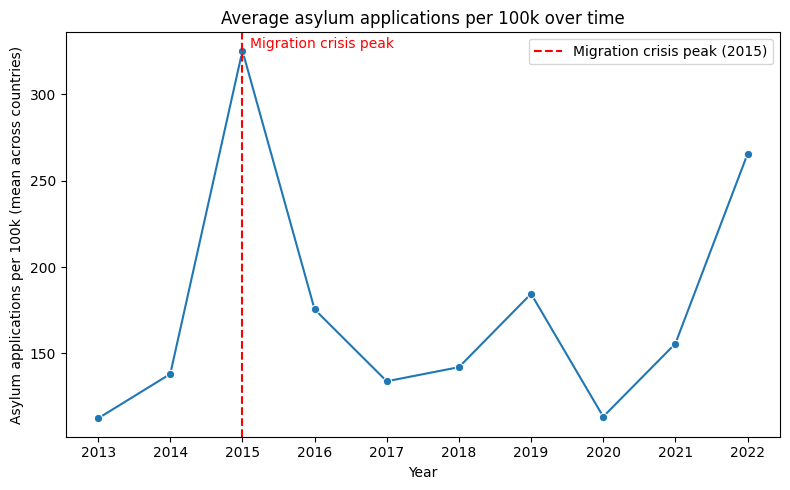

In [26]:
# -------------------------------------------------------------------
# Asylum intensity over time with migration crisis peak marker
# -------------------------------------------------------------------
# This cell shows the evolution of average asylum applications per 100k
# across all countries in df_proc and marks the migration crisis peak year.

MIGRATION_CRISIS_YEAR = 2015  # adjust if you prefer a different reference year
try:
    asylum_trend = df_proc.groupby("year")["asylum_per_100k"].mean().sort_index()
except NameError:
    raise RuntimeError("df_proc is not defined. Run the data loading/configuration cell first.")

plt.figure(figsize=(8, 5))
sns.lineplot(x=asylum_trend.index, y=asylum_trend.values, marker="o")
plt.axvline(MIGRATION_CRISIS_YEAR, color="red", linestyle="--", linewidth=1.5,
            label=f"Migration crisis peak ({MIGRATION_CRISIS_YEAR})")

peak_y = asylum_trend.get(MIGRATION_CRISIS_YEAR, asylum_trend.max())
plt.text(MIGRATION_CRISIS_YEAR + 0.1, peak_y, "Migration crisis peak",
         color="red", va="bottom", ha="left")

plt.title("Average asylum applications per 100k over time")
plt.xlabel("Year")
plt.ylabel("Asylum applications per 100k (mean across countries)")
plt.xticks(sorted(asylum_trend.index))
plt.legend()
plt.tight_layout()
plt.show()